In [2]:
import gymnasium as gym
import numpy as np
from collections import defaultdict

# 1. Environment Setup
env = gym.make('FrozenLake8x8-v1', is_slippery=True, render_mode=None)
n_states = env.observation_space.n
n_actions = env.action_space.n

print(f"Number of states: {n_states}")
print(f"Number of actions: {n_actions}")

# 2. Q(λ) Agent Class
class QLambdaAgent:
    def __init__(self, n_states, n_actions, gamma=0.99, alpha=0.05, lambda_=0.7,
                 epsilon=1.0, min_epsilon=0.01, epsilon_decay=0.9999):
        self.n_states = n_states
        self.n_actions = n_actions
        self.gamma = gamma
        self.alpha = alpha
        self.lambda_ = lambda_
        self.epsilon = epsilon
        self.min_epsilon = min_epsilon
        self.epsilon_decay = epsilon_decay

        self.Q = defaultdict(lambda: np.zeros(n_actions))
        self.eligibility_traces = defaultdict(lambda: np.zeros(n_actions))

    def choose_action(self, state):
        if np.random.rand() < self.epsilon:
            return np.random.choice(self.n_actions)
        q_values = self.Q[state]
        max_actions = np.flatnonzero(q_values == np.max(q_values))
        return np.random.choice(max_actions)


    def update(self, state, action, reward, next_state, done):
        best_next_action = np.argmax(self.Q[next_state])
        td_target = reward + (1 - done) * self.gamma * self.Q[next_state][best_next_action]
        td_error = td_target - self.Q[state][action]

        # Update eligibility trace
        self.eligibility_traces[state][action] += 1

        # Q(λ) Update
        for s in self.eligibility_traces:
            for a in range(self.n_actions):
                trace = self.eligibility_traces[s][a]
                if trace != 0:
                    self.Q[s][a] += self.alpha * td_error * trace
                    self.Q[s][a] = np.clip(self.Q[s][a], -1000, 1000)
                    self.eligibility_traces[s][a] *= self.gamma * self.lambda_
                    self.eligibility_traces[s][a] = np.clip(self.eligibility_traces[s][a], -1000, 1000)

        if done:
            self.eligibility_traces.clear()

    def decay_epsilon(self):
        self.epsilon = max(self.min_epsilon, self.epsilon * self.epsilon_decay)

# 3. Training Loop
def train_agent(agent, env, n_episodes=50000, batch_size=10000):
    rewards_history = []
    success_rates = []

    print("\nTraining Q(λ) Agent...")

    for episode in range(n_episodes):
        state, info = env.reset()
        done = False
        truncated = False
        total_reward = 0

        while not done and not truncated:
            action = agent.choose_action(state)
            next_state, reward, done, truncated, info = env.step(action)

            agent.update(state, action, reward, next_state, done)
            total_reward += reward
            state = next_state

        rewards_history.append(total_reward)
        agent.decay_epsilon()

        if (episode + 1) % batch_size == 0:
            avg_reward = np.mean(rewards_history[-batch_size:])
            success_rate = 100 * np.sum(rewards_history[-batch_size:]) / batch_size
            print(f"Episode {episode + 1}/{n_episodes} | Avg Reward: {avg_reward:.4f} | "
                  f"Success Rate: {success_rate:.2f}% | Epsilon: {agent.epsilon:.4f}")
            success_rates.append(success_rate)

    print("Training complete.")
    return rewards_history, success_rates

# 4. Initialize and Train
optimized_agent = QLambdaAgent(
    n_states=n_states,
    n_actions=n_actions,
    gamma=0.99,
    alpha=0.05,        # Reduced learning rate
    lambda_=0.7,
    epsilon=1.0,
    min_epsilon=0.01,
    epsilon_decay=0.9999
)

rewards_history, success_rates = train_agent(optimized_agent, env, n_episodes=50000, batch_size=10000)

# Close environment
env.close()

Number of states: 64
Number of actions: 4

Training Q(λ) Agent...
Episode 10000/50000 | Avg Reward: 0.0081 | Success Rate: 0.81% | Epsilon: 0.3679
Episode 20000/50000 | Avg Reward: 0.0127 | Success Rate: 1.27% | Epsilon: 0.1353
Episode 30000/50000 | Avg Reward: 0.2056 | Success Rate: 20.56% | Epsilon: 0.0498
Episode 40000/50000 | Avg Reward: 0.6310 | Success Rate: 63.10% | Epsilon: 0.0183
Episode 50000/50000 | Avg Reward: 0.7381 | Success Rate: 73.81% | Epsilon: 0.0100
Training complete.


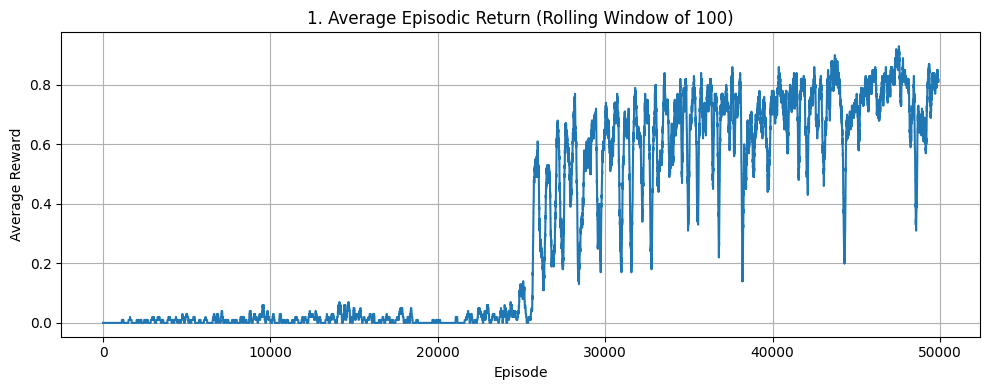

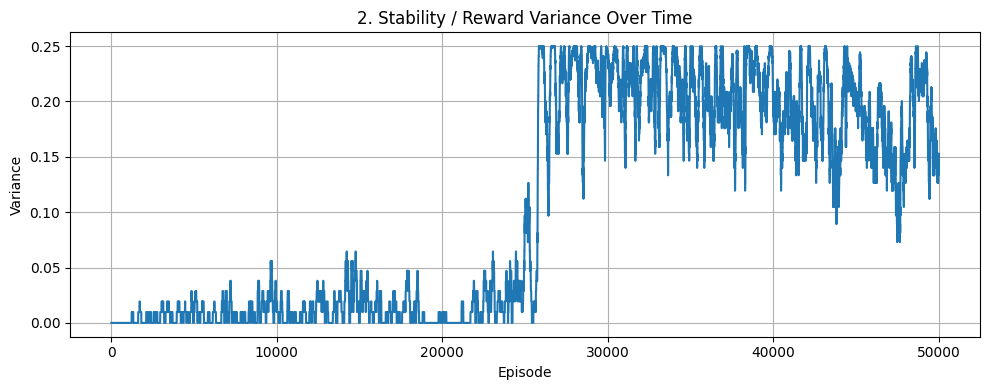

🚀 Sample Efficiency: 33645 episodes to reach ≥90% of best average return (0.8370)


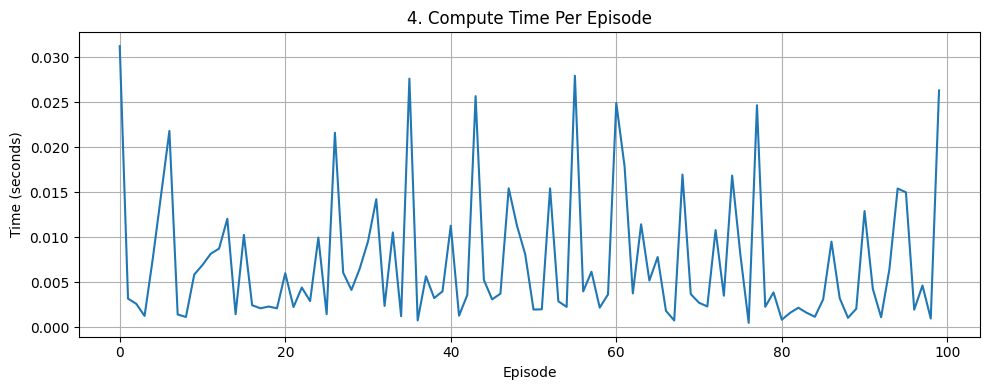

⏱️ Avg compute time per episode (sample): 0.0073 seconds
📈 Convergence Rate: 200 episodes


In [3]:
import matplotlib.pyplot as plt
import time
import numpy as np

# ------- 1. Average Episodic Return (Rolling Average) -------
window = 100
rolling_avg = np.convolve(rewards_history, np.ones(window)/window, mode='valid')

plt.figure(figsize=(10, 4))
plt.plot(rolling_avg)
plt.title("1. Average Episodic Return (Rolling Window of 100)")
plt.xlabel("Episode")
plt.ylabel("Average Reward")
plt.grid(True)
plt.tight_layout()
plt.show()

# ------- 2. Stability / Variance of Return Over Episodes -------
variance = [np.var(rewards_history[max(0, i - window):i + 1]) for i in range(len(rewards_history))]

plt.figure(figsize=(10, 4))
plt.plot(variance)
plt.title("2. Stability / Reward Variance Over Time")
plt.xlabel("Episode")
plt.ylabel("Variance")
plt.grid(True)
plt.tight_layout()
plt.show()

# ------- 3. Sample Efficiency -------
best_avg_return = np.max(rolling_avg)
threshold = 0.9 * best_avg_return
sample_efficiency = next((i for i, val in enumerate(rolling_avg) if val >= threshold), None)

print(f"🚀 Sample Efficiency: {sample_efficiency + window if sample_efficiency else 'Not Reached'} episodes "
      f"to reach ≥90% of best average return ({threshold:.4f})")

# ------- 4. Compute Time / Update Efficiency -------
# Re-run training with time tracking if needed
episode_times = []

# Re-run training loop if you want per-episode timing (skip if already tracked)
agent = QLambdaAgent(n_states=n_states, n_actions=n_actions)
for episode in range(100):  # Just 100 episodes for quick demo
    start_time = time.time()
    state, _ = env.reset()
    done = False
    while not done:
        action = agent.choose_action(state)
        next_state, reward, done, _, _ = env.step(action)
        agent.update(state, action, reward, next_state, done)
        state = next_state
    episode_times.append(time.time() - start_time)

plt.figure(figsize=(10, 4))
plt.plot(episode_times)
plt.title("4. Compute Time Per Episode")
plt.xlabel("Episode")
plt.ylabel("Time (seconds)")
plt.grid(True)
plt.tight_layout()
plt.show()

print(f"⏱️ Avg compute time per episode (sample): {np.mean(episode_times):.4f} seconds")

# ------- 5. Convergence Rate -------
def detect_convergence(rolling_avg, eps=0.0005, window=100):
    for i in range(window, len(rolling_avg)):
        recent = rolling_avg[i - window:i]
        if np.all(np.abs(np.diff(recent)) < eps):
            return i + window
    return None

convergence_ep = detect_convergence(rolling_avg)
print(f"📈 Convergence Rate: {convergence_ep if convergence_ep else 'Not Converged'} episodes")


In [4]:
print("\n📊 Final Evaluation Summary:")
print(f"🎯 Best Rolling Avg Return   : {best_avg_return:.4f}")
print(f"🚀 Sample Efficiency         : {sample_efficiency + window if sample_efficiency else 'Not Reached'}")
print(f"⏱️  Avg Compute Time/Ep      : {np.mean(episode_times):.4f} sec")
print(f"📈 Convergence Rate          : {convergence_ep if convergence_ep else 'Not Converged'}")



📊 Final Evaluation Summary:
🎯 Best Rolling Avg Return   : 0.9300
🚀 Sample Efficiency         : 33645
⏱️  Avg Compute Time/Ep      : 0.0073 sec
📈 Convergence Rate          : 200


In [5]:
def detect_convergence(rolling_avg, eps=0.001, window=100):
    for i in range(window, len(rolling_avg)):
        recent_window = rolling_avg[i - window:i]
        if np.all(np.abs(np.diff(recent_window)) < eps):
            return i + window
    return None

convergence_rate = detect_convergence(rolling_avg)
print(f"📈 Convergence Rate: {convergence_rate if convergence_rate else 'Not Converged'} episodes")


📈 Convergence Rate: 200 episodes


In [6]:
print("\n📊 Final Evaluation Summary:")
print(f"🎯 Best Avg Return           : {best_avg_return:.4f}")
print(f"🚀 Sample Efficiency         : {sample_efficiency + window if sample_efficiency else 'Not Reached'}")
print(f"⏱️  Avg Compute Time/Episode : {np.mean(episode_times):.4f} sec")
print(f"📈 Convergence Rate          : {convergence_rate if convergence_rate else 'Not Converged'}")



📊 Final Evaluation Summary:
🎯 Best Avg Return           : 0.9300
🚀 Sample Efficiency         : 33645
⏱️  Avg Compute Time/Episode : 0.0073 sec
📈 Convergence Rate          : 200
